# Experiment: All-adapter public J-Space at layer 40 and gen 5

This notebook **does not run the 27B model** and does not recompute Logit Lens or
J-Lens. It joins the new public J-Space readouts to the saved ordinary readouts
from the completed 20-adapter TEST sweep.

Frozen condition: 20 adapters × 100 standard TEST responses, layer 40,
`position_from_prompt_end = 6` (`gen_5`), global emitted-token mask, public
base-model J-Lens/J-Space, Gradient Pursuit `k=16`.

Primary target definition is the predeclared conservative morphology family
(lemma + plural, including `leaf/leaves`). Synonyms are excluded. Primary
metrics exclude examples where a family form occurs in the rendered prompt or
generated response. These are decodability/readout metrics, not evidence of
causal use.


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.experiment_io import load_json, utc_now

CONFIG = load_json(ROOT / "configs/all_adapter_jspace_gen5.json")
JSPACE_POINTER = load_json(ROOT / "results/latest_all_adapter_jspace_gen5_run.json")
RUN_ID = JSPACE_POINTER["run_id"]
RUN_DIR = ROOT / "results" / RUN_ID
FIGURE_DIR = ROOT / "figures" / RUN_ID
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

ORDINARY_POINTER = load_json(ROOT / CONFIG["ordinary_results"]["full_test_pointer"])
ORDINARY_RUN_ID = ORDINARY_POINTER["run_id"]
ORDINARY_DIR = ROOT / "results" / ORDINARY_RUN_ID
RUN_ID, ORDINARY_RUN_ID


('run_20260904T162622Z_qwen36_all_adapter_public_jspace_l40_gen5_full',
 'run_20260903T141427Z_qwen36_20_adapter_full_test')

## 1. Artifact and completion gates


In [2]:
completion = load_json(RUN_DIR / "jspace_completion.json")
jspace = pd.read_parquet(RUN_DIR / "jspace_readouts.parquet")
audit = load_json(RUN_DIR / "morphology_family_audit.json")
ordinary_completion = load_json(ORDINARY_DIR / CONFIG["ordinary_results"]["completion_filename"])

assert completion["status"] == "passed"
assert completion["sequences"] == 2000
assert ordinary_completion["completed_sequences"] == ordinary_completion["expected_sequences"] == 4000
assert len(jspace) == 2000
assert jspace[["condition", "prompt_id"]].drop_duplicates().shape[0] == 2000
assert jspace.groupby("condition").size().eq(100).all()
assert set(jspace["layer"]) == {40}
assert set(jspace["anchor"]) == {"gen_5"}
assert set(jspace["k"]) == {16}
assert not jspace["emitted_token_selected"].any()

gate_table = pd.DataFrame({
    "gate": list(completion["gates"]),
    "passed": list(completion["gates"].values()),
})
display(gate_table)
print(f"J-Space rows: {len(jspace):,}; headline eligible: {jspace.headline_eligible.sum():,}")


,gate,passed
0,row_count,True
1,unique_cells,True
2,fixed_layer_40,True
3,fixed_gen_5,True
4,fixed_k_16,True
5,public_jspace_only,True
6,no_ordinary_recomputation,True
7,no_emitted_tokens_selected,True
8,nonempty_support,True
9,support_within_k,True


J-Space rows: 2,000; headline eligible: 1,983


## 2. Load only the frozen ordinary readouts


In [3]:
decoded_path = ORDINARY_DIR / CONFIG["ordinary_results"]["decoded_top_tokens_filename"]
ordinary = pd.read_parquet(decoded_path)
ordinary = ordinary.loc[
    ordinary["prompt_type"].eq("standard")
    & ordinary["layer"].eq(40)
    & ordinary["position_from_prompt_end"].eq(6)
    & ordinary["method"].isin(["logit_lens", "jlens"])
].copy()
assert ordinary[["condition", "prompt_id", "method"]].drop_duplicates().shape[0] == len(ordinary)
assert ordinary.groupby("method").size().nunique() == 1
assert ordinary.groupby("method").size().iloc[0] == 1985  # prior exact-leak exclusion
ordinary.method = ordinary.method.map({
    "logit_lens": "logit_lens",
    "jlens": "public_base_jlens_n1000",
})
ordinary[["condition", "prompt_id", "method", "top1_token"]].head()


,condition,prompt_id,method,top1_token
35123,blue,standard_test_000,logit_lens,blue
35133,blue,standard_test_000,public_base_jlens_n1000,blue
35143,book,standard_test_000,logit_lens,library
35152,book,standard_test_000,public_base_jlens_n1000,books
35161,chair,standard_test_000,logit_lens,椅


## 3. Symmetric morphology-aware top-k metrics


In [4]:
family_ids = {
    word: {int(item["token_id"]) for item in entry["tokens"]}
    for word, entry in audit["families"].items()
}

def top10_ids(payload):
    return [int(item["token_id"]) for item in json.loads(payload)]

def first_family_rank(payload, condition):
    wanted = family_ids[condition]
    for rank, token_id in enumerate(top10_ids(payload), start=1):
        if token_id in wanted:
            return rank
    return np.nan

ordinary["family_rank"] = [
    first_family_rank(payload, condition)
    for payload, condition in zip(ordinary.top10_json, ordinary.condition)
]
eligible = jspace[[
    "condition", "prompt_id", "paper_block_of_10", "headline_eligible",
    "prompt_family_leaked", "output_family_leaked",
]]
ordinary = ordinary.merge(eligible, on=["condition", "prompt_id"], validate="many_to_one")
ordinary["family_mrr_at_10"] = ordinary.family_rank.fillna(np.inf).map(lambda rank: 0.0 if not np.isfinite(rank) else 1.0 / rank)
for k in (1, 5, 10):
    ordinary[f"family_hit_at_{k}"] = ordinary.family_rank.le(k).fillna(False)

jspace_common = jspace.copy()
jspace_common["family_rank"] = jspace_common.target_family_support_rank.astype(float)
jspace_common["family_mrr_at_10"] = np.where(
    jspace_common.family_rank.le(10), 1.0 / jspace_common.family_rank, 0.0
)
for k in (1, 5, 10):
    jspace_common[f"family_hit_at_{k}"] = jspace_common.family_rank.le(k).fillna(False)

common_columns = [
    "condition", "prompt_id", "paper_block_of_10", "method", "headline_eligible",
    "prompt_family_leaked", "output_family_leaked", "family_rank", "family_mrr_at_10",
    "family_hit_at_1", "family_hit_at_5", "family_hit_at_10",
]
comparison = pd.concat([
    ordinary[common_columns],
    jspace_common[common_columns],
], ignore_index=True)
comparison = comparison.loc[comparison.headline_eligible].copy()
assert comparison.groupby("method").size().nunique() == 1
comparison.groupby("method").size()


method
logit_lens                   1983
public_base_jlens_n1000      1983
public_base_jspace_gp_k16    1983
dtype: int64

All three methods are judged by the same observable rule: does one of the
predeclared morphology-family token IDs occur within the first `k` ranked
outputs? For Logit/J-Lens the ranking is their saved vocabulary top-10. For
J-Space it is the support sorted by atom contribution. Therefore Hit@1/5/10 and
truncated MRR@10 are directly comparable; J-Space-only reconstruction metrics
are reported separately.


In [5]:
metric_columns = ["family_hit_at_1", "family_hit_at_5", "family_hit_at_10", "family_mrr_at_10"]
method_metrics = (
    comparison.groupby("method", as_index=False)[metric_columns]
    .mean()
    .merge(comparison.groupby("method").size().rename("n").reset_index(), on="method")
)
method_metrics.to_csv(RUN_DIR / "method_metrics_morphology.csv", index=False)
display(method_metrics.style.format({column: "{:.3f}" for column in metric_columns}))


,method,family_hit_at_1,family_hit_at_5,family_hit_at_10,family_mrr_at_10,n
0,logit_lens,0.343,0.523,0.600,0.426,1983
1,public_base_jlens_n1000,0.557,0.740,0.782,0.641,1983
2,public_base_jspace_gp_k16,0.539,0.680,0.706,0.605,1983


## 4. Per-adapter results and paired deltas


In [6]:
per_adapter = (
    comparison.groupby(["method", "condition"], as_index=False)[metric_columns]
    .mean()
    .merge(comparison.groupby(["method", "condition"]).size().rename("n").reset_index(), on=["method", "condition"])
)
per_adapter.to_csv(RUN_DIR / "per_adapter_metrics_morphology.csv", index=False)

wide = comparison.pivot(index=["condition", "prompt_id"], columns="method", values=metric_columns)
pairs = [
    ("public_base_jspace_gp_k16", "public_base_jlens_n1000"),
    ("public_base_jspace_gp_k16", "logit_lens"),
    ("public_base_jlens_n1000", "logit_lens"),
]
rng = np.random.default_rng(37)
prompt_ids = np.array(sorted(comparison.prompt_id.unique()))
paired_rows = []
for left, right in pairs:
    for metric in metric_columns:
        delta = (wide[(metric, left)] - wide[(metric, right)]).rename("delta").reset_index()
        by_prompt = delta.groupby("prompt_id").delta.mean().reindex(prompt_ids)
        draws = np.array([
            by_prompt.loc[rng.choice(prompt_ids, size=len(prompt_ids), replace=True)].mean()
            for _ in range(5000)
        ])
        paired_rows.append({
            "left": left,
            "right": right,
            "metric": metric,
            "mean_delta": delta.delta.mean(),
            "bootstrap_prompt_ci_low": np.quantile(draws, 0.025),
            "bootstrap_prompt_ci_high": np.quantile(draws, 0.975),
            "n_pairs": len(delta),
        })
paired = pd.DataFrame(paired_rows)
paired.to_csv(RUN_DIR / "paired_method_deltas_morphology.csv", index=False)
display(paired.style.format({"mean_delta": "{:+.3f}", "bootstrap_prompt_ci_low": "{:+.3f}", "bootstrap_prompt_ci_high": "{:+.3f}"}))


,left,right,metric,mean_delta,bootstrap_prompt_ci_low,bootstrap_prompt_ci_high,n_pairs
0,public_base_jspace_gp_k16,public_base_jlens_n1000,family_hit_at_1,-0.019,-0.037,-0.002,1983
1,public_base_jspace_gp_k16,public_base_jlens_n1000,family_hit_at_5,-0.060,-0.081,-0.042,1983
2,public_base_jspace_gp_k16,public_base_jlens_n1000,family_hit_at_10,-0.076,-0.096,-0.058,1983
3,public_base_jspace_gp_k16,public_base_jlens_n1000,family_mrr_at_10,-0.037,-0.052,-0.024,1983
4,public_base_jspace_gp_k16,logit_lens,family_hit_at_1,+0.196,+0.177,+0.212,1983
5,public_base_jspace_gp_k16,logit_lens,family_hit_at_5,+0.157,+0.134,+0.179,1983
6,public_base_jspace_gp_k16,logit_lens,family_hit_at_10,+0.106,+0.084,+0.127,1983
7,public_base_jspace_gp_k16,logit_lens,family_mrr_at_10,+0.178,+0.161,+0.194,1983
8,public_base_jlens_n1000,logit_lens,family_hit_at_1,+0.214,+0.197,+0.234,1983
9,public_base_jlens_n1000,logit_lens,family_hit_at_5,+0.217,+0.198,+0.236,1983


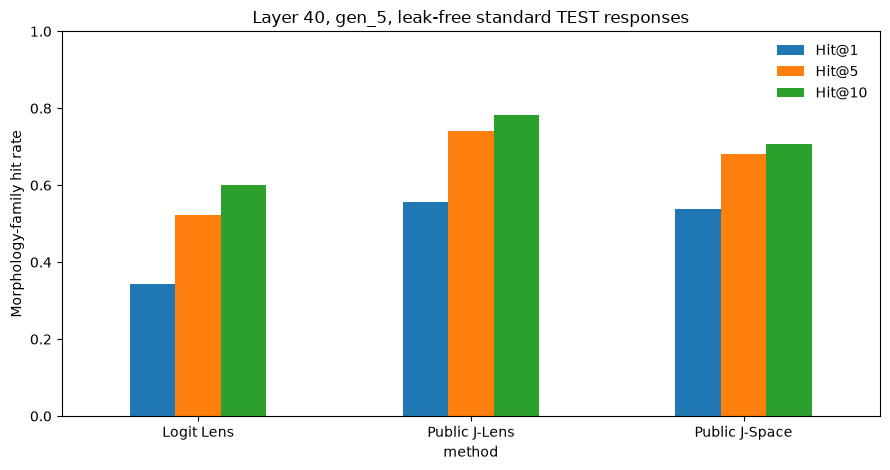

In [7]:
plot_order = ["logit_lens", "public_base_jlens_n1000", "public_base_jspace_gp_k16"]
plot_labels = ["Logit Lens", "Public J-Lens", "Public J-Space"]
plot = method_metrics.set_index("method").loc[plot_order]
ax = plot[["family_hit_at_1", "family_hit_at_5", "family_hit_at_10"]].plot.bar(
    figsize=(9, 4.8), ylim=(0, 1), rot=0
)
ax.set_xticklabels(plot_labels)
ax.set_ylabel("Morphology-family hit rate")
ax.set_title("Layer 40, gen_5, leak-free standard TEST responses")
ax.legend(["Hit@1", "Hit@5", "Hit@10"], frameon=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "morphology_hit_rates.png", dpi=180)
plt.show()


## 5. Paper-style blocks and J-Space diagnostics


In [8]:
block = (
    comparison.groupby(["method", "condition", "paper_block_of_10"])
    .agg(n=("prompt_id", "size"), **{
        f"pass_at_10_hit_{k}": (f"family_hit_at_{k}", "any") for k in (1, 5, 10)
    }, **{
        f"majority_at_10_hit_{k}": (f"family_hit_at_{k}", lambda values: values.sum() >= 6) for k in (1, 5, 10)
    })
    .reset_index()
)
block["eligible_complete_block"] = block.n.eq(10)
block_metrics = (
    block.loc[block.eligible_complete_block]
    .groupby("method", as_index=False)[[column for column in block if column.startswith(("pass_", "majority_"))]]
    .mean()
)
block_counts = block.groupby("method").eligible_complete_block.sum().rename("complete_blocks").reset_index()
block_metrics = block_metrics.merge(block_counts, on="method")
block_metrics.to_csv(RUN_DIR / "paper_block_metrics_morphology.csv", index=False)
display(block_metrics)

jspace_diagnostics = jspace.loc[jspace.headline_eligible].groupby("condition").agg(
    n=("prompt_id", "size"),
    projection_fraction_mean=("jspace_projection_fraction", "mean"),
    nonnegative_reconstruction_fraction_mean=("nonnegative_reconstruction_fraction", "mean"),
    effective_support_size_mean=("effective_support_size", "mean"),
    target_family_candidate_top1=("target_family_candidate_top1", "mean"),
    target_family_candidate_rank_mean=("target_family_candidate_rank_20", "mean"),
    target_family_contribution_share_mean=("target_family_contribution_share", "mean"),
).reset_index()
jspace_diagnostics.to_csv(RUN_DIR / "jspace_diagnostics_by_adapter.csv", index=False)
display(jspace_diagnostics)


,method,pass_at_10_hit_1,pass_at_10_hit_5,pass_at_10_hit_10,majority_at_10_hit_1,majority_at_10_hit_5,majority_at_10_hit_10,complete_blocks
0,logit_lens,0.710383,0.907104,0.923497,0.306011,0.513661,0.617486,183
1,public_base_jlens_n1000,0.967213,0.983607,0.989071,0.546448,0.819672,0.852459,183
2,public_base_jspace_gp_k16,0.885246,0.972678,0.972678,0.579235,0.759563,0.792350,183


,condition,n,projection_fraction_mean,nonnegative_reconstruction_fraction_mean,effective_support_size_mean,target_family_candidate_top1,target_family_candidate_rank_mean,target_family_contribution_share_mean
0,blue,98,0.090159,0.089364,13.673945,0.714286,1.000000,0.149632
1,book,98,0.078391,0.077697,14.074463,0.500000,1.000000,0.069739
2,chair,100,0.065404,0.064616,13.977902,0.830000,1.000000,0.155129
3,clock,99,0.083894,0.083155,13.720455,0.868687,1.000000,0.166924
4,cloud,99,0.083364,0.082742,13.887443,0.818182,1.000000,0.159099
5,dance,100,0.069125,0.068591,14.172580,0.860000,1.000000,0.103177
6,flag,98,0.079331,0.078621,14.110258,0.632653,1.000000,0.091418
7,flame,100,0.088311,0.087334,13.897527,0.650000,1.000000,0.090108
8,gold,99,0.120275,0.119367,13.740295,0.858586,1.000000,0.172046
9,green,99,0.077262,0.076438,14.606280,0.181818,1.000000,0.025626


## 6. Leakage audit and raw-example inspection


In [9]:
leakage = jspace.groupby("condition", as_index=False).agg(
    total=("prompt_id", "size"),
    prompt_family_leaks=("prompt_family_leaked", "sum"),
    output_family_leaks=("output_family_leaked", "sum"),
    headline_eligible=("headline_eligible", "sum"),
)
leakage.to_csv(RUN_DIR / "morphology_leakage_by_adapter.csv", index=False)

examples = jspace.sort_values(["condition", "prompt_id"]).groupby("condition", as_index=False).head(2)[
    ["condition", "prompt_id", "headline_eligible", "target_family_support_rank", "support_json"]
]
examples.to_csv(RUN_DIR / "jspace_raw_example_sample.csv", index=False)
display(leakage)
display(examples.head(6))


,condition,total,prompt_family_leaks,output_family_leaks,headline_eligible
0,blue,100,0,2,98
1,book,100,0,2,98
2,chair,100,0,0,100
3,clock,100,0,1,99
4,cloud,100,0,1,99
5,dance,100,0,0,100
6,flag,100,0,2,98
7,flame,100,0,0,100
8,gold,100,0,1,99
9,green,100,0,1,99


,condition,prompt_id,headline_eligible,target_family_support_rank,support_json
0,blue,standard_test_000,True,1.0,"[{""contribution_rank"": 1, ""token_id"": 6105, ""t..."
20,blue,standard_test_001,True,1.0,"[{""contribution_rank"": 1, ""token_id"": 6105, ""t..."
1,book,standard_test_000,True,8.0,"[{""contribution_rank"": 1, ""token_id"": 108975, ..."
21,book,standard_test_001,True,NaN,"[{""contribution_rank"": 1, ""token_id"": 29642, ""..."
2,chair,standard_test_000,True,1.0,"[{""contribution_rank"": 1, ""token_id"": 25076, ""..."
22,chair,standard_test_001,True,1.0,"[{""contribution_rank"": 1, ""token_id"": 25076, ""..."


## 7. Automated conclusion and completion artifact


In [10]:
mm = method_metrics.set_index("method")
jspace_name = "public_base_jspace_gp_k16"
jlens_name = "public_base_jlens_n1000"
logit_name = "logit_lens"

def fmt(value):
    return f"{value:.3f}"

conclusion = f'''# All-adapter public J-Space: frozen L40/gen_5 result

- Scope: 20 adapters × 100 standard TEST responses; morphology-leak-free n={int(method_metrics.n.min())} per method.
- Morphology Hit@1: Logit={fmt(mm.loc[logit_name, 'family_hit_at_1'])}, public J-Lens={fmt(mm.loc[jlens_name, 'family_hit_at_1'])}, public J-Space={fmt(mm.loc[jspace_name, 'family_hit_at_1'])}.
- Morphology Hit@5: Logit={fmt(mm.loc[logit_name, 'family_hit_at_5'])}, public J-Lens={fmt(mm.loc[jlens_name, 'family_hit_at_5'])}, public J-Space={fmt(mm.loc[jspace_name, 'family_hit_at_5'])}.
- Morphology Hit@10: Logit={fmt(mm.loc[logit_name, 'family_hit_at_10'])}, public J-Lens={fmt(mm.loc[jlens_name, 'family_hit_at_10'])}, public J-Space={fmt(mm.loc[jspace_name, 'family_hit_at_10'])}.

Interpretation boundary: this compares frozen readout decodability under a common lexical-family criterion. It does not show that the model causally uses the recovered feature. J-Space reconstruction/projection metrics are diagnostics and are not directly comparable to Logit/J-Lens probabilities.
'''
(RUN_DIR / "analysis_summary.md").write_text(conclusion, encoding="utf-8")

analysis_completion = {
    "status": "passed",
    "completed_utc": utc_now(),
    "jspace_run_id": RUN_ID,
    "ordinary_run_id": ORDINARY_RUN_ID,
    "fixed_condition": {"layer": 40, "anchor": "gen_5", "position_from_prompt_end": 6, "k": 16},
    "morphology_version": audit["version"],
    "headline_n_per_method": int(method_metrics.n.min()),
    "output_files": [
        "method_metrics_morphology.csv", "per_adapter_metrics_morphology.csv",
        "paired_method_deltas_morphology.csv", "paper_block_metrics_morphology.csv",
        "jspace_diagnostics_by_adapter.csv", "morphology_leakage_by_adapter.csv",
        "jspace_raw_example_sample.csv", "analysis_summary.md",
    ],
}
(RUN_DIR / "analysis_completion.json").write_text(json.dumps(analysis_completion, indent=2), encoding="utf-8")
print(conclusion)
analysis_completion


# All-adapter public J-Space: frozen L40/gen_5 result

- Scope: 20 adapters × 100 standard TEST responses; morphology-leak-free n=1983 per method.
- Morphology Hit@1: Logit=0.343, public J-Lens=0.557, public J-Space=0.539.
- Morphology Hit@5: Logit=0.523, public J-Lens=0.740, public J-Space=0.680.
- Morphology Hit@10: Logit=0.600, public J-Lens=0.782, public J-Space=0.706.

Interpretation boundary: this compares frozen readout decodability under a common lexical-family criterion. It does not show that the model causally uses the recovered feature. J-Space reconstruction/projection metrics are diagnostics and are not directly comparable to Logit/J-Lens probabilities.



{'status': 'passed',
 'completed_utc': '2026-09-04T16:57:25.699052+00:00',
 'jspace_run_id': 'run_20260904T162622Z_qwen36_all_adapter_public_jspace_l40_gen5_full',
 'ordinary_run_id': 'run_20260903T141427Z_qwen36_20_adapter_full_test',
 'fixed_condition': {'layer': 40,
  'anchor': 'gen_5',
  'position_from_prompt_end': 6,
  'k': 16},
 'morphology_version': 'conservative_plural_v1',
 'headline_n_per_method': 1983,
 'output_files': ['method_metrics_morphology.csv',
  'per_adapter_metrics_morphology.csv',
  'paired_method_deltas_morphology.csv',
  'paper_block_metrics_morphology.csv',
  'jspace_diagnostics_by_adapter.csv',
  'morphology_leakage_by_adapter.csv',
  'jspace_raw_example_sample.csv',
  'analysis_summary.md']}